   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002  

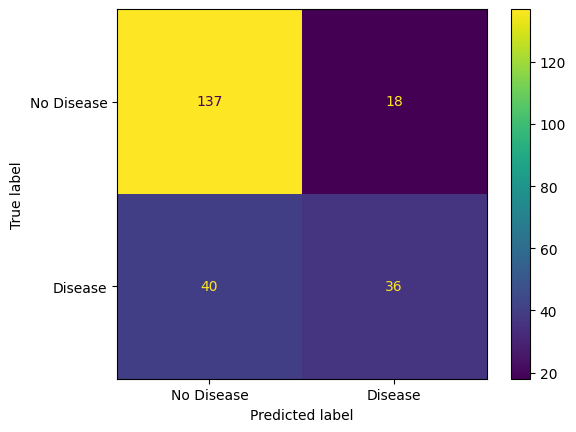

In [1]:
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np 
import pandas as pd 

'''You've been called in as a machine learning
detective. A renowned expert has developed a
cutting-edge model to predict diabetes, but
something's amiss. Despite their expertise, the
model appears to be underperforming. After
some investigation, you discover the culprit:
they're using regression metrics to evaluate a
classification problem!
Your challenge: to save the day by training a
Logistic Regression model using the provided
dataset. Then, display the confusion matrix to
uncover the real performance of the model.
'''
df = pd.read_csv("/kaggle/input/dia-csv/diabetes.csv")
print(df.head())
print()
print(df.describe())
print()
print(df.shape)

df["Outcome"].value_counts()
X = df.drop(columns = "Outcome", axis = 1)
Y = df["Outcome"]

print(X)
print(Y)

# standardizing the data
scaler = StandardScaler()
scaler.fit(X)
standardize_data = scaler.transform(X)
print(standardize_data)

X = standardize_data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.3, random_state = 2)
print(X.shape, X_train.shape, X_test.shape)

#model
model = LogisticRegression()

#train the model
model.fit(X_train, Y_train)

#evaluate the model
X_train_pred = model.predict(X_train)
trainingdata_accuarcy = metrics.accuracy_score(X_train_pred, Y_train)
print(trainingdata_accuarcy)
X_test_pred = model.predict(X_test)
testingdata_accuarcy = metrics.accuracy_score(X_test_pred, Y_test)
print(testingdata_accuarcy)

# creating confusion matrix
cm = metrics.confusion_matrix(Y_test, X_test_pred)
print(cm)

#plot
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Disease", "Disease"])
disp.plot()
